In [2]:
"""
Notebook 03: Data Aggregation
=============================
Load full 2023, clean, aggregate to hourly time series
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# Setup
DATA_DIR = Path("../data/raw")
PROCESSE_DIR = Path("../data/processed")
PROCESSE_DIR.mkdir(parents=True, exist_ok=True)

# plt.style.use('default')
# sns.set_palette("husl")

In [3]:
def load_year_data(year: int = 2023, taxi_type: str = "yellow") -> pd.DataFrame:
    """
    Load all monthly parquet files for a given year and concatenate.
    Args:
        year: Year of data to load.
        taxi_type: 'yellow' or 'green'

    Returns:
        Concatenated DataFrame with all months.
    """

    # We only read the needed columns - save the computer memory
    columns_needed = [
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'passenger_count',
        'trip_distance',
        'total_amount',
        'fare_amount',
        'PULocationID',
        'DOLocationID'
    ]

    monthly_dfs = []
    # tqdm is always import to get feedback from the process
    for month in tqdm(range(1, 13), desc=f"loading {year}"):
        filename = f"{taxi_type}_tripdata_{year}-{month:02d}.parquet"
        filepath = DATA_DIR / filename

        if not filepath.exists():
            print(f"Missing: {filename}")
            continue
        # Parquet is column-oriented, thus it is going to read the needed columns
        # Parquet has a huge advantage opposite to CSV
        df_month = pd.read_parquet(filepath, columns=columns_needed)
        monthly_dfs.append(df_month)

    df = pd.concat(monthly_dfs, ignore_index=True)
    print(f" Loaded {len(df):,} rows total") # more visible
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
    # deep = True, If it isn't adjusted, than it won't calculate correectly
    # the strings columns 
    return df


In [4]:
%%time
df_full = load_year_data(2023)

loading 2023: 100%|██████████| 12/12 [00:02<00:00,  4.25it/s]


 Loaded 38,310,226 rows total
Memory usage: 2.45 GB
CPU times: total: 8.28 s
Wall time: 3.96 s


In [5]:
df_full.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,total_amount,fare_amount,PULocationID,DOLocationID
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,14.30,9.3,161,141
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,16.90,7.9,43,237
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,34.90,14.9,48,238
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,20.85,12.1,138,7
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,19.68,11.4,107,79


In [6]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38310226 entries, 0 to 38310225
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   total_amount           float64       
 5   fare_amount            float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
dtypes: datetime64[us](2), float64(4), int64(2)
memory usage: 2.3 GB


In [7]:
def clean_taxi_data(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Clean NYC taxi data based on data quality audit findings.

    Removes:
        - Negative or zero total amount (refunds, errors)
        - Negative or zero trip distance
        - Negative trip duration (pickup > dropoff)
        - Trips longer then 12 hours (outliers)
        - Tips with passenger_count == 0 or Nan

    Args:
        df: Raw Dataframe
        verbose: Print cleaning statistics

    Returns:
        Cleaned Dataframe
    """

    initial_rows = len(df)
    df = df.copy()

    # 1. Calculate trip duration in minutes
    df['trip_duration_min'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60

    # Define filters
    filters = {
        'positive_amount': df['total_amount'] > 0,
        'positive_distance': df['trip_distance'] > 0,
        'positive_duration': df['trip_duration_min'] > 0,
        'reasonable_duration': df['trip_duration_min'] <= 12 * 60, # max 12 hours
        'has_passengers': (df['passenger_count'].notna()) & df['passenger_count'] > 0,
        'valid_pickup_year': df['tpep_pickup_datetime'].dt.year == 2023
    }

    # 3. Apply filters cumulatively, track losses
    if verbose:
        print(f"Initial rows: {initial_rows:,}")
        print("-" * 50)

    combined_mask = pd.Series(True, index=df.index)
    for filter_name, filter_mask in filters.items():
        before = combined_mask.sum()
        combined_mask &= filter_mask
        after = combined_mask.sum()
        removed = before - after
        if verbose:
            print(f' {filter_name:25s}: removed {removed:>10,} rows')

    df_clean = df[combined_mask].copy()

    if verbose:
        print("-" * 50)
        print(f"Final rows: {len(df_clean):,}")
        print(f"Removed: {initial_rows - len(df_clean):,} ({(1 - len(df_clean)/initial_rows) * 100:.2f}%)")

    return df_clean

In [8]:
df_clean = clean_taxi_data(df_full)

Initial rows: 38,310,226
--------------------------------------------------
 positive_amount          : removed    382,882 rows
 positive_distance        : removed    728,205 rows
 positive_duration        : removed      3,262 rows
 reasonable_duration      : removed     28,770 rows
 has_passengers           : removed  1,583,150 rows
 valid_pickup_year        : removed         66 rows
--------------------------------------------------
Final rows: 35,583,891
Removed: 2,726,335 (7.12%)


In [9]:
print("=== Trip distance analysis ===")
print(f"Total rows: {len(df_full):,}")
print(f"Negative distance: {(df_full['trip_distance'] < 0).sum():,}")
print(f"Zero distance:     {(df_full['trip_distance'] == 0).sum():,}")
print(f"Positive distance: {(df_full['trip_distance'] > 0).sum():,}")
print()
print("=== Per month: zero distance count ===")
print(df_full.groupby(df_full['tpep_pickup_datetime'].dt.month)['trip_distance']
      .apply(lambda x: (x == 0).sum()))

=== Trip distance analysis ===
Total rows: 38,310,226
Negative distance: 0
Zero distance:     773,457
Positive distance: 37,536,769

=== Per month: zero distance count ===
tpep_pickup_datetime
1      45861
2      41175
3      48450
4      40235
5      46892
6      47472
7      49791
8      57427
9      98546
10    121689
11    102586
12     73333
Name: trip_distance, dtype: int64


In [10]:
print("=== Passenger count problems per month ===")
problems_per_month = df_full.groupby(df_full['tpep_pickup_datetime'].dt.month).apply(
    lambda x: pd.Series({
        'total': len(x),
        'zero_passenger': (x['passenger_count'] == 0).sum(),
        'nan_passenger': x['passenger_count'].isnull().sum(),
        'problem_pct': ((x['passenger_count'] == 0) | x['passenger_count'].isnull()).sum() / len(x) * 100
    })
)
print(problems_per_month)

=== Passenger count problems per month ===
                          total  zero_passenger  nan_passenger  problem_pct
tpep_pickup_datetime                                                       
1                     3066759.0         51164.0        71743.0     4.007716
2                     2914003.0         47278.0        76817.0     4.258575
3                     3403660.0         58364.0        87619.0     4.289001
4                     3288248.0         56950.0        90690.0     4.489929
5                     3513664.0         59725.0       101796.0     4.596939
6                     3307259.0         54231.0        99887.0     4.659992
7                     2907093.0         43732.0        85086.0     4.431162
8                     2824201.0         41898.0        87886.0     4.595424
9                     2846741.0         39136.0       140225.0     6.300573
10                    3522280.0         46634.0       154929.0     5.722515
11                    3339732.0         41443

In [11]:
print("=== Pickup years in the 2023 data ===")
year_counts = df_full['tpep_pickup_datetime'].dt.year.value_counts().sort_index()
print(year_counts)

=== Pickup years in the 2023 data ===
tpep_pickup_datetime
2001           6
2002          11
2003           6
2008          23
2009          15
2014           1
2022          36
2023    38310122
2024           6
Name: count, dtype: int64


In [12]:
df_long = df_full.copy()
df_long['duration_min'] = (
    df_long['tpep_dropoff_datetime'] - df_long['tpep_pickup_datetime']
).dt.total_seconds() / 60
print(df_long.nlargest(10, 'duration_min')[
    ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'duration_min', 'trip_distance', 'total_amount']
])

         tpep_pickup_datetime tpep_dropoff_datetime  duration_min  \
2127658   2023-01-23 11:21:51   2023-01-30 10:31:02  10029.183333   
15333535  2023-05-24 12:51:56   2023-05-31 11:19:03   9987.116667   
23763760  2023-08-16 08:19:21   2023-08-22 16:36:26   9137.083333   
22522817  2023-08-02 11:05:52   2023-08-08 17:20:46   9014.900000   
25058918  2023-08-31 08:33:05   2023-09-05 11:05:12   7352.116667   
20624865  2023-07-14 12:52:23   2023-07-19 15:21:13   7348.833333   
23771787  2023-08-16 10:56:52   2023-08-21 12:03:43   7266.850000   
36632962  2023-12-15 11:42:05   2023-12-20 11:30:24   7188.316667   
5337796   2023-02-23 14:59:05   2023-02-28 12:32:42   7053.616667   
24845732  2023-08-28 18:13:03   2023-09-02 10:57:12   6764.150000   

          trip_distance  total_amount  
2127658            0.00          4.50  
15333535           0.00          4.50  
23763760           0.00          4.50  
22522817           0.00          5.20  
25058918           0.00          4.50  


In [13]:
def aggregate_hourly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate taxi trips to hourly demand time series.

    Args:
        df: Cleaned DataFrame with 'tpep_pickup_datetime' column.

    Returns:
        DataFrame with columns: hour, trip_count, avg_distance,
        avg_duration_min, total_revenue.
    """
    df = df.copy()

    # Floor to hour: 2023-01-15 14:37:22 -> 2023-01-15 14:00:00
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.floor('h')

    # Aggregate
    hourly = df.groupby('pickup_hour').agg(
        trip_count=('tpep_pickup_datetime', 'count'),
        avg_distance=('trip_distance', 'mean'),
        avg_duration_min=('trip_duration_min', 'mean'),
        total_revenue=('total_amount', 'sum')
    ).reset_index()

    # Sort by time (should already be sorted, but safety first)
    hourly = hourly.sort_values('pickup_hour').reset_index(drop=True)

    print(f"Aggregated to {len(hourly):,} hourly buckets")
    print(f"Date range: {hourly['pickup_hour'].min()} to {hourly['pickup_hour'].max()}")
    print(f"Avg trips/hour: {hourly['trip_count'].mean():.0f}")
    print(f"Medain trips/hour: {hourly['trip_count'].median():.0f}")
    print(f"Max trips/hour: {hourly['trip_count'].max():,}")
    print(f"Min trips/hour: {hourly['trip_count'].min():,}")

    return hourly

In [14]:
df_hourly = aggregate_hourly(df_clean)
df_hourly.head(24)
df_hourly.tail(24)
df_hourly.info()

Aggregated to 8,724 hourly buckets
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
Avg trips/hour: 4079
Medain trips/hour: 4670
Max trips/hour: 10,273
Min trips/hour: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   pickup_hour       8724 non-null   datetime64[us]
 1   trip_count        8724 non-null   int64         
 2   avg_distance      8724 non-null   float64       
 3   avg_duration_min  8724 non-null   float64       
 4   total_revenue     8724 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 340.9 KB


In [15]:
# Hozz létre egy teljes óra-tartományt (8,760 óra)
expected_hours = pd.date_range(
    start='2023-01-01 00:00:00',
    end='2023-12-31 23:00:00',
    freq='h'
)
print(f"Expected hours: {len(expected_hours):,}")
print(f"Got hours:      {len(df_hourly):,}")
print(f"Missing:        {len(expected_hours) - len(df_hourly):,}")

# Melyek a hiányzó órák?
got_hours = set(df_hourly['pickup_hour'])
missing_hours = sorted(set(expected_hours) - got_hours)

print(f"\nFirst 10 missing hours:")
for h in missing_hours[:10]:
    print(f"  {h}")

print(f"\nLast 10 missing hours:")
for h in missing_hours[-10:]:
    print(f"  {h}")

# Mintázat ellenőrzés: melyik hónapban hány óra hiányzik?
missing_by_month = pd.Series(missing_hours).dt.month.value_counts().sort_index()
print(f"\nMissing hours by month:")
print(missing_by_month)

Expected hours: 8,760
Got hours:      8,724
Missing:        36

First 10 missing hours:
  2023-03-12 02:00:00
  2023-09-21 14:00:00
  2023-09-21 15:00:00
  2023-09-22 03:00:00
  2023-09-22 04:00:00
  2023-09-22 05:00:00
  2023-09-22 06:00:00
  2023-09-22 07:00:00
  2023-09-22 08:00:00
  2023-09-22 12:00:00

Last 10 missing hours:
  2023-09-23 23:00:00
  2023-09-24 00:00:00
  2023-09-24 01:00:00
  2023-09-24 02:00:00
  2023-09-24 03:00:00
  2023-09-24 04:00:00
  2023-09-24 05:00:00
  2023-09-24 06:00:00
  2023-09-24 07:00:00
  2023-09-24 08:00:00

Missing hours by month:
3     1
9    35
Name: count, dtype: int64


In [16]:
def fill_missing_hours(df_hourly: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Fill missings hours using seasonal (same-hour-previous-week) imputation.

    Strategy:
        1. Reindex to complete hourly range (8,760 hours for 2023)
        2. For each missing hour, look up same hour 7 days earlier
        3. If that's also missing, look 14 days earlier, the forward fill
        4. Track which rows were imputed via 'is_imputed' flag

    Args:
        df_hourly: Aggregated hourly DataFrame with 'pickup_hour' column.
        verbose: Print statistics.

    Returns:
        Complete hourly DataFrame with imputation flag.
    """

    df = df_hourly.copy()
    df = df.set_index('pickup_hour')

    # 1. Complete hourly range
    full_range = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq='h'
    )
    df_reindexed = df.reindex(full_range)
    df_reindexed.index.name = 'pickup_hour'

    # 2. Mark imputed rows BEFORE filling
    df_reindexed['is_imputed'] = df_reindexed['trip_count'].isna()
    n_imputed = df_reindexed['is_imputed'].sum()

    # 3. Seasonal imputation: same hour, 7 days earlier
    numeric_cols = ['trip_count', 'avg_distance', 'avg_duration_min', 'total_revenue']

    for col in numeric_cols:
        # Try same hour 7 days earlier:
        df_reindexed[col] = df_reindexed[col].fillna(
            df_reindexed[col].shift(24 * 7)
        )
        # If still NaN, try 14 days earlier
        df_reindexed[col] = df_reindexed[col].fillna(
            df_reindexed[col].shift(24 * 14)
        )
        # Last resort: forward fill (very rare)
        df_reindexed[col] = df_reindexed[col].ffill()

    df_reindexed = df_reindexed.reset_index()

    if verbose:
        print(f"Filled {n_imputed} missing hours")
        print(f"Total hours now: {len(df_reindexed):,}")
        print(f"Imputed: {n_imputed} ({n_imputed/len(df_reindexed)*100:.2f}%)")
        print(f"Real data: {len(df_reindexed) - n_imputed:,}")

    return df_reindexed


In [ ]:
df_hourly_full = fill_missing_hours(df_hourly)
df_hourly_full.head()
df_hourly.info()

print(f"\nFinal shape: {df_hourly_full.shape}")
print(f"\nImputed hours: {df_hourly_full['is_imputed'].sum()}")
print(f"\nImputed hours by date:")
print(df_hourly_full[df_hourly_full['is_imputed']]['pickup_hour'].dt.date.value_counts().sort_index())

Filled 36 missing hours
Total hours now: 8,760
Imputed: 36 (0.41%)
Real data: 8,724
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   pickup_hour       8724 non-null   datetime64[us]
 1   trip_count        8724 non-null   int64         
 2   avg_distance      8724 non-null   float64       
 3   avg_duration_min  8724 non-null   float64       
 4   total_revenue     8724 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 340.9 KB

Final shape: (8760, 6)

Imputed hours: 36

IMputed hours by date:
pickup_hour
2023-03-12     1
2023-09-21     2
2023-09-22    11
2023-09-23    13
2023-09-24     9
Name: count, dtype: int64


In [18]:
nov_5 = df_hourly[
    (df_hourly['pickup_hour'] >= '2023-11-05 00:00') &
    (df_hourly['pickup_hour'] < '2023-11-05 06:00')
]
print(nov_5)

             pickup_hour  trip_count  avg_distance  avg_duration_min  \
7356 2023-11-05 00:00:00        5361      3.006378         14.177016   
7357 2023-11-05 01:00:00        6806      2.540486         11.763549   
7358 2023-11-05 02:00:00        2058      2.759334         11.291181   
7359 2023-11-05 03:00:00        1204      3.013870         11.334884   
7360 2023-11-05 04:00:00         757      3.811110         12.296808   
7361 2023-11-05 05:00:00         885      5.413412         13.995160   

      total_revenue  
7356      138442.77  
7357      154516.07  
7358       47192.64  
7359       29159.53  
7360       21891.90  
7361       31884.32  


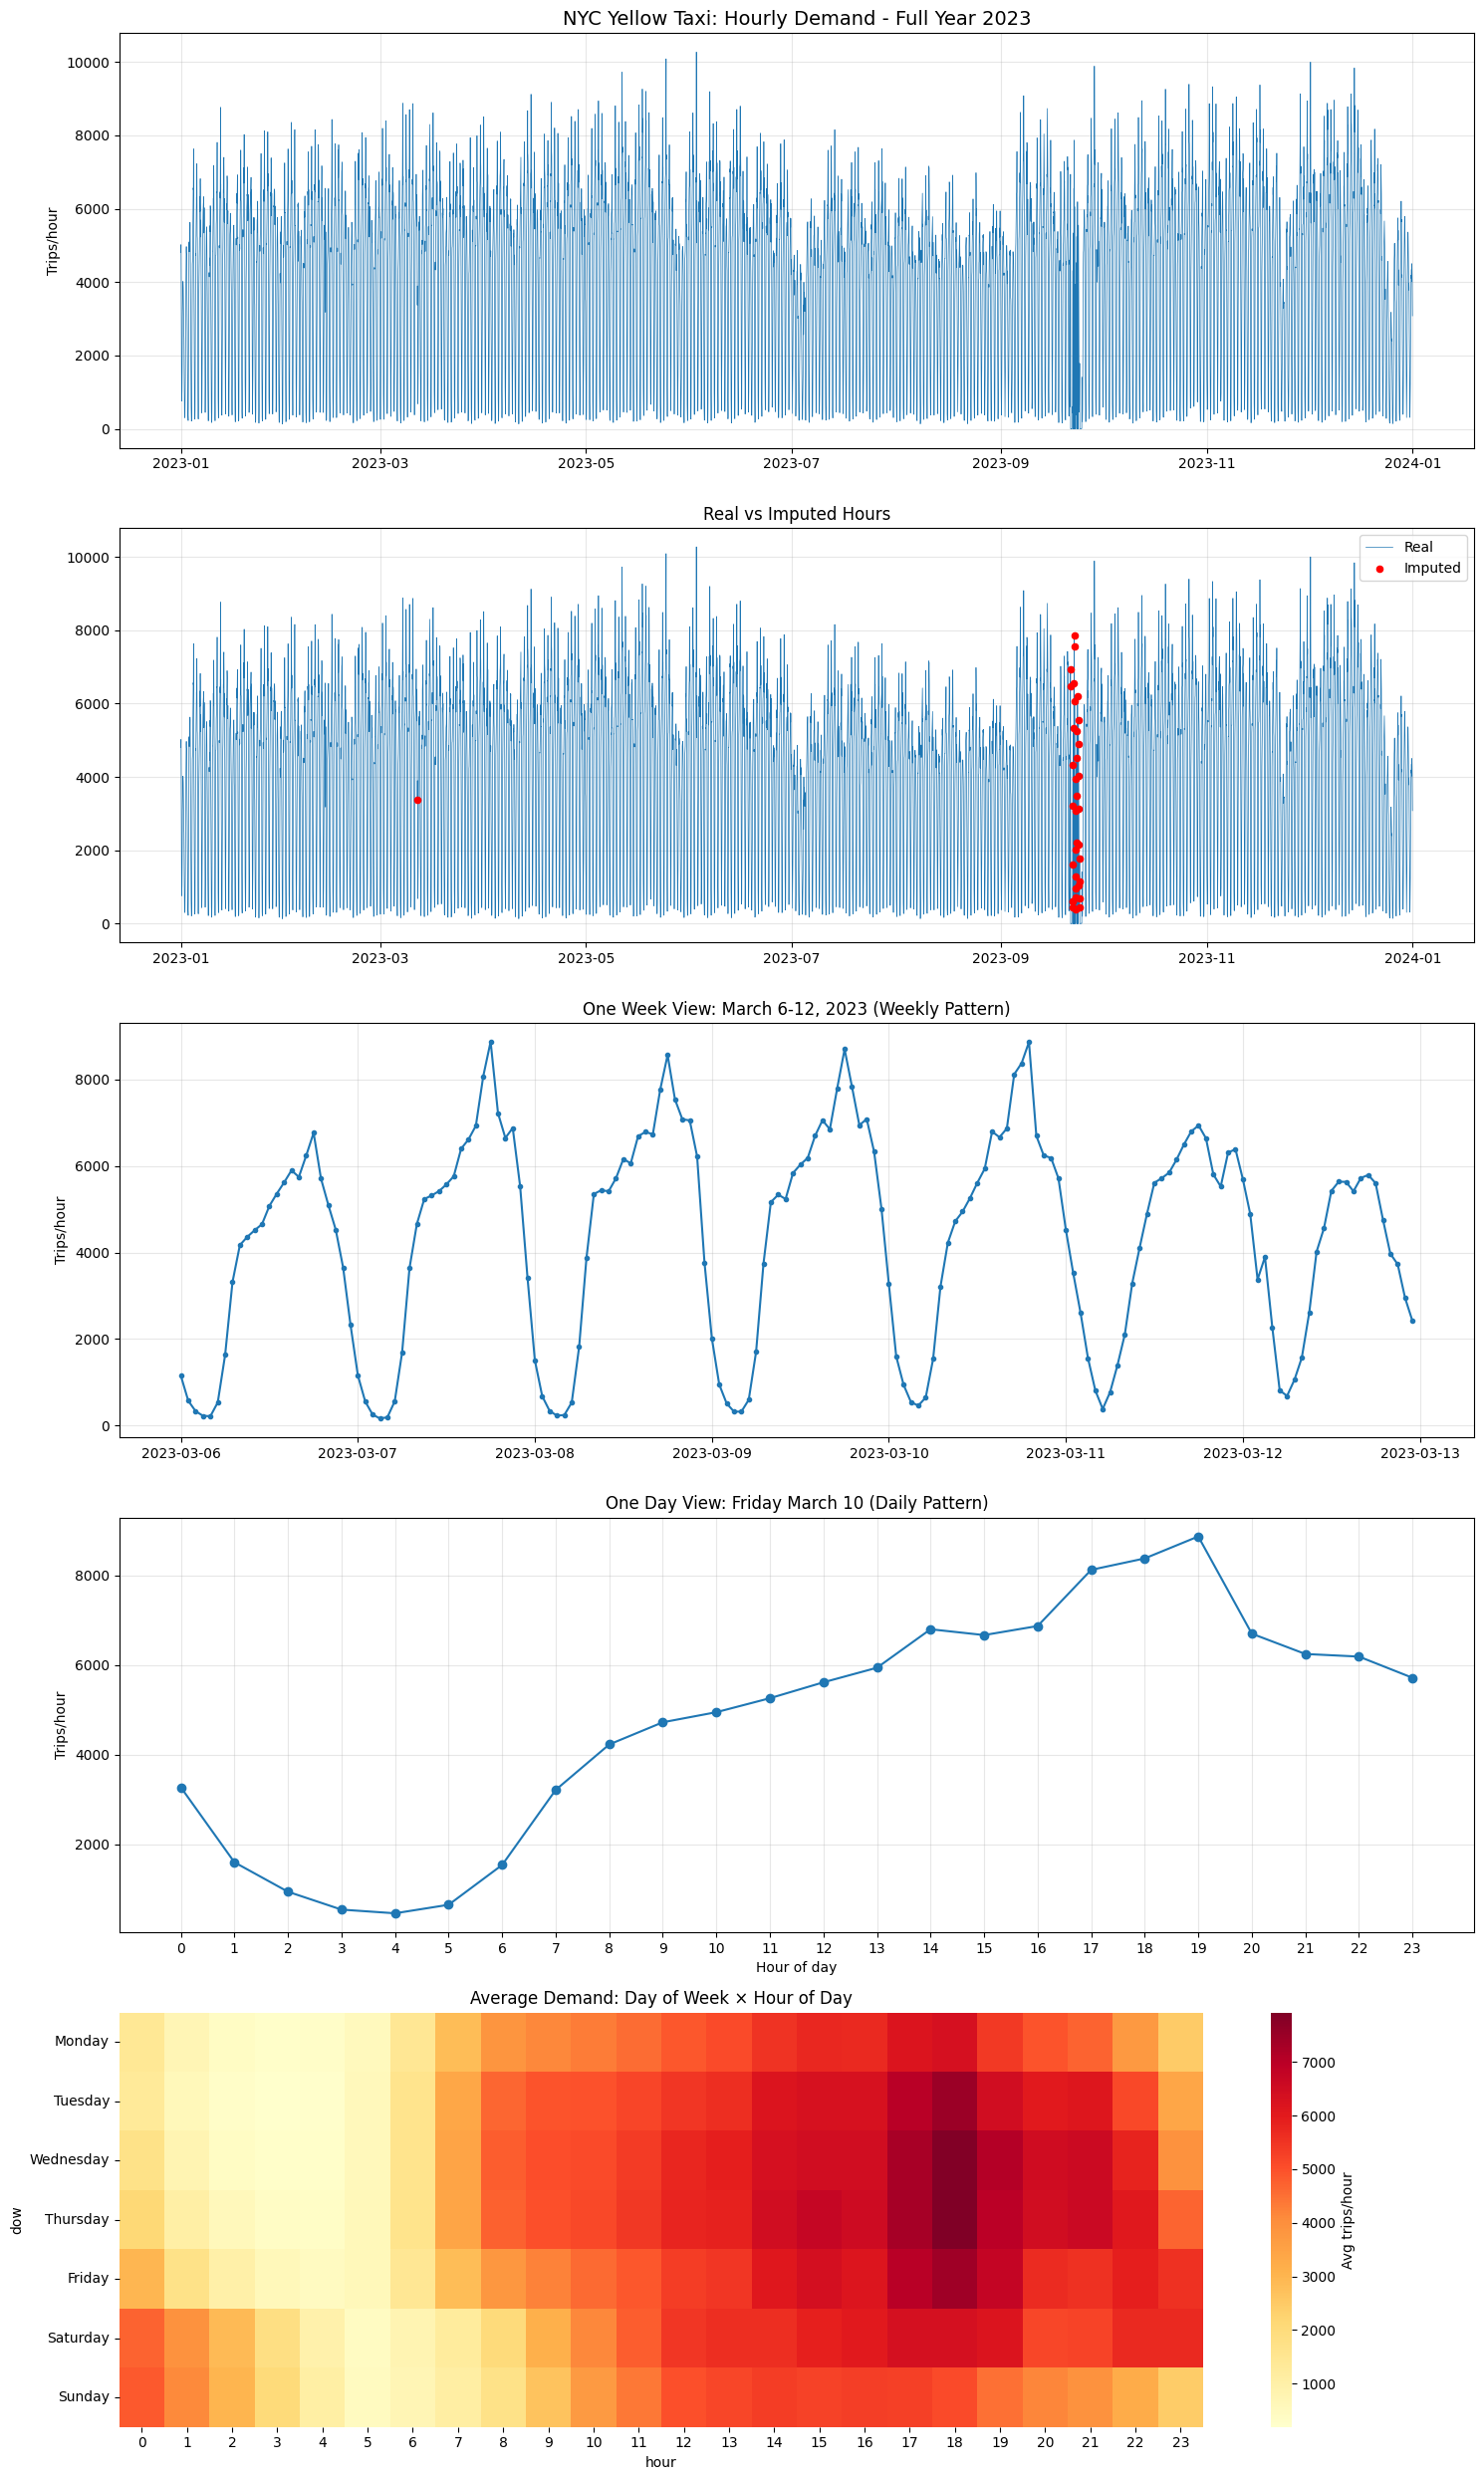

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(15, 25))

# Plot 1: Whole year
axes[0].plot(df_hourly_full['pickup_hour'], df_hourly_full['trip_count'], linewidth=0.5)
axes[0].set_title('NYC Yellow Taxi: Hourly Demand - Full Year 2023', fontsize=14)
axes[0].set_ylabel('Trips/hour')
axes[0].grid(True, alpha=0.3)

# Plot 2: Mark imputed hours
axes[1].plot(df_hourly_full['pickup_hour'], df_hourly_full['trip_count'], 
             linewidth=0.5, label='Real')
imputed = df_hourly_full[df_hourly_full['is_imputed']]
axes[1].scatter(imputed['pickup_hour'], imputed['trip_count'], 
                color='red', s=20, label='Imputed', zorder=5)
axes[1].set_title('Real vs Imputed Hours')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: One week (March 6-12, before DST)
week_data = df_hourly_full[
    (df_hourly_full['pickup_hour'] >= '2023-03-06') &
    (df_hourly_full['pickup_hour'] < '2023-03-13')
]
axes[2].plot(week_data['pickup_hour'], week_data['trip_count'], marker='o', markersize=3)
axes[2].set_title('One Week View: March 6-12, 2023 (Weekly Pattern)')
axes[2].set_ylabel('Trips/hour')
axes[2].grid(True, alpha=0.3)

# Plot 4: One day (Friday for max activity)
day_data = df_hourly_full[
    (df_hourly_full['pickup_hour'] >= '2023-03-10') &
    (df_hourly_full['pickup_hour'] < '2023-03-11')
]
axes[3].plot(day_data['pickup_hour'].dt.hour, day_data['trip_count'], marker='o')
axes[3].set_title('One Day View: Friday March 10 (Daily Pattern)')
axes[3].set_xlabel('Hour of day')
axes[3].set_ylabel('Trips/hour')
axes[3].set_xticks(range(0, 24))
axes[3].grid(True, alpha=0.3)

# Plot 5: Heatmap (day of week × hour)
df_hourly_full['dow'] = df_hourly_full['pickup_hour'].dt.day_name()
df_hourly_full['hour'] = df_hourly_full['pickup_hour'].dt.hour
heatmap_data = df_hourly_full.pivot_table(
    values='trip_count',
    index='dow',
    columns='hour',
    aggfunc='mean'
)
# Sort days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

import seaborn as sns
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[4], cbar_kws={'label': 'Avg trips/hour'})
axes[4].set_title('Average Demand: Day of Week × Hour of Day')

plt.tight_layout()
plt.savefig('../docs/hourly_demand_overview.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
output_path = PROCESSE_DIR / 'hourly_taxi_demand_2023.parquet'
df_hourly_full.to_parquet(output_path, index=False)
print(f"Saved to_ {output_path}")
print(f"Size: {output_path.stat().st_size / 1024:.1f} KB")

Saved to_ ..\data\processed\hourly_taxi_demand_2023.parquet
Size: 347.8 KB
